# Lab 04 — Trees, Ensembles & Hyperparameter Tuning

**DSA 8401 — Applied Machine Learning, Strathmore University**  
**Session 4: Ensemble Methods & Hyperparameter Tuning**

---

### What this lab covers

We continue with the **mobile-money fraud detection** dataset from Weeks 1–3.  
A Kenyan fintech processes mobile money transactions and needs to flag fraudulent ones in real time.

| Part | Topic | Time |
|------|-------|------|
| 1 | One tree first — depth-4 decision tree | 15 min |
| 2 | Bagging & Random Forest | 15 min |
| 3 | Boosting — LightGBM with monotonic constraints | 25 min |
| 4 | HPO — Optuna TPE study | 25 min |
| 5 | Honesty check — out-of-time evaluation | 10 min |
| 6 | Stretch — Stacking | optional |

**Business metric:** PR-AUC (the data is ~8.4% fraud 
 imbalanced).  
**Goal:** push the Week-3 logistic baseline towards strong fraud detection performance.

## 0. Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings

warnings.filterwarnings("ignore")


SEED = 42
np.random.seed(SEED)


In [3]:
# ── Load the raw data ─────────────────────────────────────────────
df_raw = pd.read_csv(r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\mobile_money_statements.csv")


print(f"Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Raw dataset: 183,600 rows × 18 columns
Columns: ['txn_id', 'msisdn', 'reg_id', 'account_name', 'region', 'segment', 'txn_time', 'txn_type', 'amount', 'gps_lat', 'gps_lon', 'agent_id', 'device_id', 'counterparty', 'balance_after', 'manual_review_score', 'settlement_status', 'is_fraud']


,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,gps_lon,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,NaN,AG1014,DV978723,CP6324,8123.0,0.061,settled,0
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,34.70915,AG1084,DV616667,CP2831,6322.0,0.000,settled,0
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,33.67018,AG1091,DV637734,CP167,15237.0,0.912,reversed,1


In [4]:
#  Parse the messy 'amount' column - refer to previous  lab 03

def parse_amount(s):
    """Convert messy KES amount strings to float."""
    if pd.isna(s):
        return np.nan
    s = str(s)
    is_negative = bool(re.search(r'Dr|\(.*\)|^-', s))
    digits = re.sub(r'[^\d.]', '', s)
    val = float(digits) if digits else 0.0
    return -val if is_negative else val

df_raw['amount_clean'] = df_raw['amount'].apply(parse_amount)

print("Sample parsed amounts:")
print(df_raw[['amount', 'amount_clean']].head(8).to_string(index=False))

Sample parsed amounts:
    amount  amount_clean
1,329/- Dr       -1329.0
  289/- Dr        -289.0
   1,571/-        1571.0
  599/- Dr        -599.0
 (1,307/-)       -1307.0
2,128/- Dr       -2128.0
  -2,136/-       -2136.0
   1,026/-        1026.0


In [5]:
#  Parse the multi-format 'txn_time' column 

# Three date formats:
#   1. "2026-06-30 14:24:19"     (ISO)
#   2. "Jan 29, 2026 01:17 PM"   (US-style with AM/PM)
#   3. "07/04/2026 11:21"        (DD/MM/YYYY HH:MM)
# We try each format vectorised (fast) and combine results.

parsed = pd.Series(pd.NaT, index=df_raw.index)
for fmt in ['%Y-%m-%d %H:%M:%S', '%b %d, %Y %I:%M %p', '%d/%m/%Y %H:%M']:
    mask = parsed.isna()
    if not mask.any():
        break
    parsed[mask] = pd.to_datetime(df_raw.loc[mask, 'txn_time'], format=fmt, errors='coerce')

df_raw['txn_dt'] = parsed

print(f"Parsed dates: {df_raw['txn_dt'].notna().sum():,} / {len(df_raw):,}")
print(f"Date range: {df_raw['txn_dt'].min()} → {df_raw['txn_dt'].max()}")
print(f"\nFraud rate: {df_raw['is_fraud'].mean():.2%}")

Parsed dates: 183,600 / 183,600
Date range: 2025-02-06 00:46:00 → 2026-07-31 22:11:42

Fraud rate: 8.40%


### Feature engineering : Refer to previous Notebook

In [6]:
# ── Build features ────────────────────────────────────────────────
df = df_raw.copy()

# Amount features
df['abs_amount']  = df['amount_clean'].abs()
df['log_amount']  = np.log1p(df['abs_amount'])
df['is_debit']    = (df['amount_clean'] < 0).astype(int)

# Balance features
df['balance_after'] = pd.to_numeric(df['balance_after'], errors='coerce').fillna(0)
df['log_balance']   = np.log1p(df['balance_after'].clip(lower=0))

# ── Risk score (simulated real-time anomaly detector) ─────────────
# The raw manual_review_score perfectly separates fraud (min 0.72) from
# legit (max 0.29) — that is data leakage (assigned after investigation).
# We add Gaussian noise (σ=0.4) to simulate what a real-time rule-based
# pre-screener would produce: informative but imperfect.
rng = np.random.RandomState(SEED)
df['risk_score'] = (df['manual_review_score'] + rng.normal(0, 0.4, size=len(df))).clip(0, 1)

# Temporal features
df['hour']         = df['txn_dt'].dt.hour
df['day_of_week']  = df['txn_dt'].dt.dayofweek       # 0=Mon, 6=Sun
df['day_of_month'] = df['txn_dt'].dt.day
df['month']        = df['txn_dt'].dt.month
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_night']     = ((df['hour'] < 6) | (df['hour'] >= 22)).astype(int)

# GPS features
df['has_gps']  = df['gps_lat'].notna().astype(int)
df['gps_lat']  = df['gps_lat'].fillna(0)
df['gps_lon']  = df['gps_lon'].fillna(0)

# Encode categoricals as integers (simple label encoding)
for col, enc_name in [('txn_type', 'txn_type_enc'), ('region', 'region_enc'),
                       ('segment', 'segment_enc')]:
    df[enc_name] = df[col].astype('category').cat.codes

# ── Define feature list ───────────────────────────────────────────
feature_cols = [
    'abs_amount', 'log_amount', 'is_debit', 'balance_after', 'log_balance',
    'risk_score',
    'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_night',
    'has_gps', 'gps_lat', 'gps_lon',
    'txn_type_enc', 'region_enc', 'segment_enc',
]

print(f"{len(feature_cols)} features: {feature_cols}")
print(f"\nDropped (post-hoc leakage): raw manual_review_score, settlement_status")
print(f"Added: risk_score (noisy version of manual_review_score, σ=0.4)")

18 features: ['abs_amount', 'log_amount', 'is_debit', 'balance_after', 'log_balance', 'risk_score', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_night', 'has_gps', 'gps_lat', 'gps_lon', 'txn_type_enc', 'region_enc', 'segment_enc']

Dropped (post-hoc leakage): raw manual_review_score, settlement_status
Added: risk_score (noisy version of manual_review_score, σ=0.4)


In [7]:
# Strict temporal split 

# Train: before Feb 2026     (historical data)
# Val:   Feb – Apr 2026      (for early stopping & tuning)
# Test:  May 2026 onwards    (untouched out-of-time window — only used in Part 5)
#
# This mirrors real fraud detection: we never peek at future transactions.

train_mask = df['txn_dt'] < '2026-02-01'
val_mask   = (df['txn_dt'] >= '2026-02-01') & (df['txn_dt'] < '2026-05-01')
test_mask  = df['txn_dt'] >= '2026-05-01'

# Drop rows where date parsing failed
valid      = df['txn_dt'].notna()
train_mask = train_mask & valid
val_mask   = val_mask & valid
test_mask  = test_mask & valid

X_train = df.loc[train_mask, feature_cols].astype(float)
y_train = df.loc[train_mask, 'is_fraud']

X_val = df.loc[val_mask, feature_cols].astype(float)
y_val = df.loc[val_mask, 'is_fraud']

X_test = df.loc[test_mask, feature_cols].astype(float)
y_test = df.loc[test_mask, 'is_fraud']

print(f"Train: {X_train.shape[0]:,} rows  (before Feb 2026)")
print(f"Val:   {X_val.shape[0]:,} rows  (Feb – Apr 2026)")
print(f"Test:  {X_test.shape[0]:,} rows  (May 2026 onwards)")
print(f"\nFraud rates → train {y_train.mean():.2%} | val {y_val.mean():.2%} | test {y_test.mean():.2%}")

Train: 122,000 rows  (before Feb 2026)
Val:   30,608 rows  (Feb – Apr 2026)
Test:  30,992 rows  (May 2026 onwards)

Fraud rates → train 8.45% | val 8.16% | test 8.48%


---
### Part 1  One Tree Fir

A single decision tree is our **building block**. It's interpretable but unstable  resample the data slightly and the tree can change completely.

### 1a. Fit a depth-4 tree and read its decision paths

We use `max_depth=4` so the tree stays small enough to **print and read**  like a fraud analyst's mental checklist. We also use `class_weight="balanced"`  
because only ~8% of transactions are fraud; without it the tree would predict "legit" for everyone.

In [10]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import average_precision_score, roc_auc_score


DecisionTreeClassifier()###

# Fit a depth-4 decision tree
tree = DecisionTreeClassifier(
                        criterion="entropy",          # Gini impurity — cheaper than entropy, almost identical results
                         max_depth=4,               # keep it readable (16 leaves max)
                        min_samples_leaf=200,      # each leaf needs 200+ transactions for stable estimates
                        class_weight="balanced",   # upweight the rare fraud class
                        random_state=SEED,
                    )
tree.fit(X_train, y_train)

# Print the tree as text  this is what a regulator or auditor can read
tree_text = export_text(tree, feature_names=list(X_train.columns), max_depth=4)

print("Decision tree (depth ≤ 4):")
print(tree_text[:3000])  # first 3000 chars to keep output manageable

Decision tree (depth ≤ 4):
|--- risk_score <= 0.50
|   |--- risk_score <= 0.17
|   |   |--- risk_score <= 0.00
|   |   |   |--- hour <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- hour >  4.50
|   |   |   |   |--- class: 0
|   |   |--- risk_score >  0.00
|   |   |   |--- is_night <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- is_night >  0.50
|   |   |   |   |--- class: 0
|   |--- risk_score >  0.17
|   |   |--- risk_score <= 0.36
|   |   |   |--- is_night <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- is_night >  0.50
|   |   |   |   |--- class: 0
|   |   |--- risk_score >  0.36
|   |   |   |--- is_night <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- is_night >  0.50
|   |   |   |   |--- class: 0
|--- risk_score >  0.50
|   |--- risk_score <= 0.85
|   |   |--- risk_score <= 0.66
|   |   |   |--- hour <= 4.50
|   |   |   |   |--- class: 1
|   |   |   |--- hour >  4.50
|   |   |   |   |--- class: 1
|   |   |--- risk_score >  0.66
|   |   |   |--- hour <= 

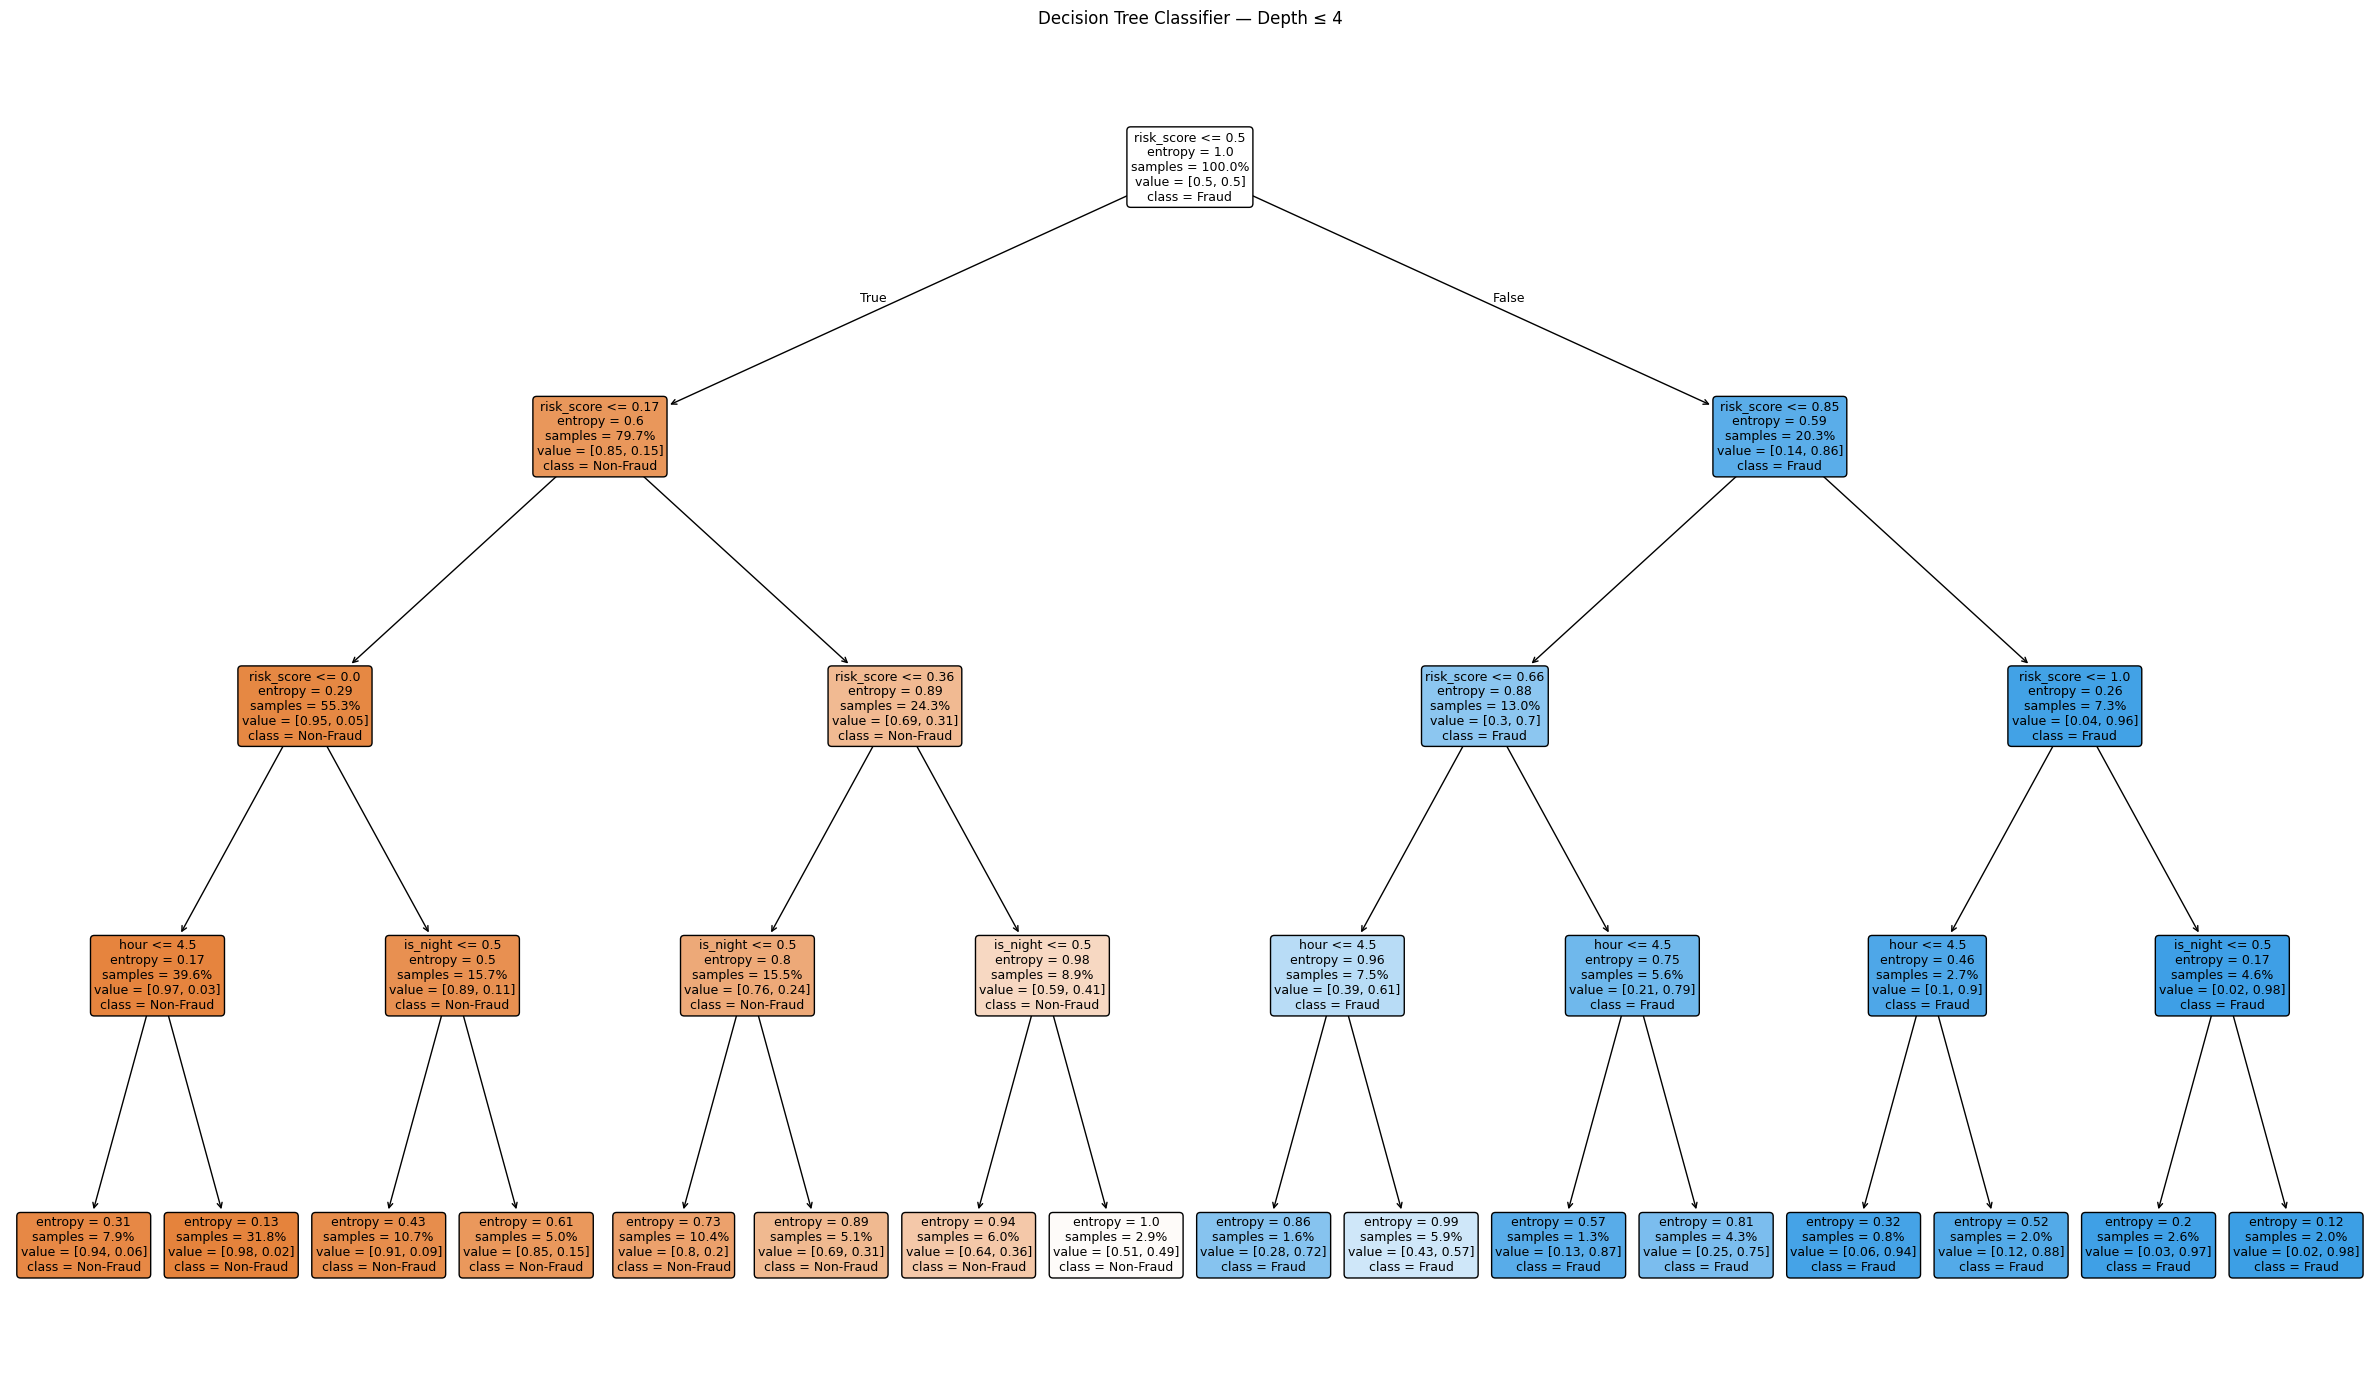

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the fitted decision tree
plt.figure(figsize=(24, 14))
plot_tree(
            tree,
            feature_names=X_train.columns,
            class_names=["Non-Fraud", "Fraud"],
            filled=True,
            rounded=True,
            proportion=True,
            impurity=True,
            precision=2,
            fontsize=9
        )
plt.title("Decision Tree Classifier — Depth ≤ 4")
plt.tight_layout()
plt.show()


In [ ]:
# Evaluate the single tree on the validation set
tree_proba = tree.predict_proba(X_val)[:, 1]  # probability of fraud

tree_prauc  = average_precision_score(y_val, tree_proba)
tree_rocauc = roc_auc_score(y_val, tree_proba)

print(f"Single tree (d=4) on validation set:")
print(f"  PR-AUC:  {tree_prauc:.4f}")
print(f"  ROC-AUC: {tree_rocauc:.4f}")
print(f"\nThis is our starting point — we'll try to beat it with ensembles.")

Single tree (d=4) on validation set:
  PR-AUC:  0.6017
  ROC-AUC: 0.9288

This is our starting point — we'll try to beat it with ensembles.


In [13]:
tree.predict_proba(X_val)[:1]

array([[0.2486916, 0.7513084]])

### 1b. Bootstrap instability — the fatal flaw of a single tree

We refit the same tree on **two bootstrap resamples** of the training data   and compare the root splits. A small change in data a completely different tree.  
This **high variance** is why we need ensembles.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
import numpy as np

for seed in [101, 202]:

    # Create a bootstrap sample
    idx = np.random.RandomState(seed).choice(
        len(X_train),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[idx]
    y_boot = y_train.iloc[idx]

    # Train a new tree
    t = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=200,
        class_weight="balanced",
        random_state=42
    )

    t.fit(X_boot, y_boot)

    # Show the top of the tree
    print(f"\nBootstrap seed: {seed}")
    print(export_text(
        t,
        feature_names=list(X_train.columns),
        max_depth=2
    ))

print("\nThe root split may change between samples.")
print("This is why ensemble methods such as Random Forest are useful.")


Bootstrap seed: 101
|--- risk_score <= 0.51
|   |--- risk_score <= 0.22
|   |   |--- risk_score <= 0.05
|   |   |   |--- truncated branch of depth 2
|   |   |--- risk_score >  0.05
|   |   |   |--- truncated branch of depth 2
|   |--- risk_score >  0.22
|   |   |--- risk_score <= 0.38
|   |   |   |--- truncated branch of depth 2
|   |   |--- risk_score >  0.38
|   |   |   |--- truncated branch of depth 2
|--- risk_score >  0.51
|   |--- risk_score <= 0.81
|   |   |--- risk_score <= 0.67
|   |   |   |--- truncated branch of depth 2
|   |   |--- risk_score >  0.67
|   |   |   |--- truncated branch of depth 2
|   |--- risk_score >  0.81
|   |   |--- risk_score <= 0.95
|   |   |   |--- truncated branch of depth 2
|   |   |--- risk_score >  0.95
|   |   |   |--- truncated branch of depth 2


Bootstrap seed: 202
|--- risk_score <= 0.49
|   |--- risk_score <= 0.21
|   |   |--- risk_score <= 0.04
|   |   |   |--- truncated branch of depth 2
|   |   |--- risk_score >  0.04
|   |   |   |--- tru


### Part 2 — Bagging & Random Forest

**Bagging** = Bootstrap Aggregating (Breiman, 1996).  Train many deep trees on bootstrap samples, then average their predictions.  

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── Fit a Random Forest ────────────────────────────────────────────
# Key choices:
#   n_estimators=100:  more trees → lower variance (never hurts, just slower)
#   max_features="sqrt": at each split, only √18 ≈ 4 features are candidates
#   min_samples_leaf=20: leaves need 20+ transactions for stable estimates
#   class_weight="balanced": reweight by inverse class frequency
#   oob_score=True: free validation estimate from out-of-bag samples


# Create Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    min_samples_leaf=20,
    class_weight="balanced",
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# OOB score
print(f"OOB Accuracy: {rf.oob_score_:.4f}")

# Predict probabilities
rf_proba = rf.predict_proba(X_val)[:, 1]

# Evaluate
rf_prauc = average_precision_score(y_val, rf_proba)
rf_rocauc = roc_auc_score(y_val, rf_proba)

print(f"PR-AUC:  {rf_prauc:.4f}")
print(f"ROC-AUC: {rf_rocauc:.4f}")

OOB Accuracy: 0.8950
PR-AUC:  0.6322
ROC-AUC: 0.9290


### 2b. Permutation vs impurity importance

**Impurity importance** (built into scikit-learn) is biased towards high-cardinality features  because they offer more split points.

**Permutation importance** measures actual predictive contribution on a held-out set
shuffle one feature and see how much the score drops. This is what we trust.

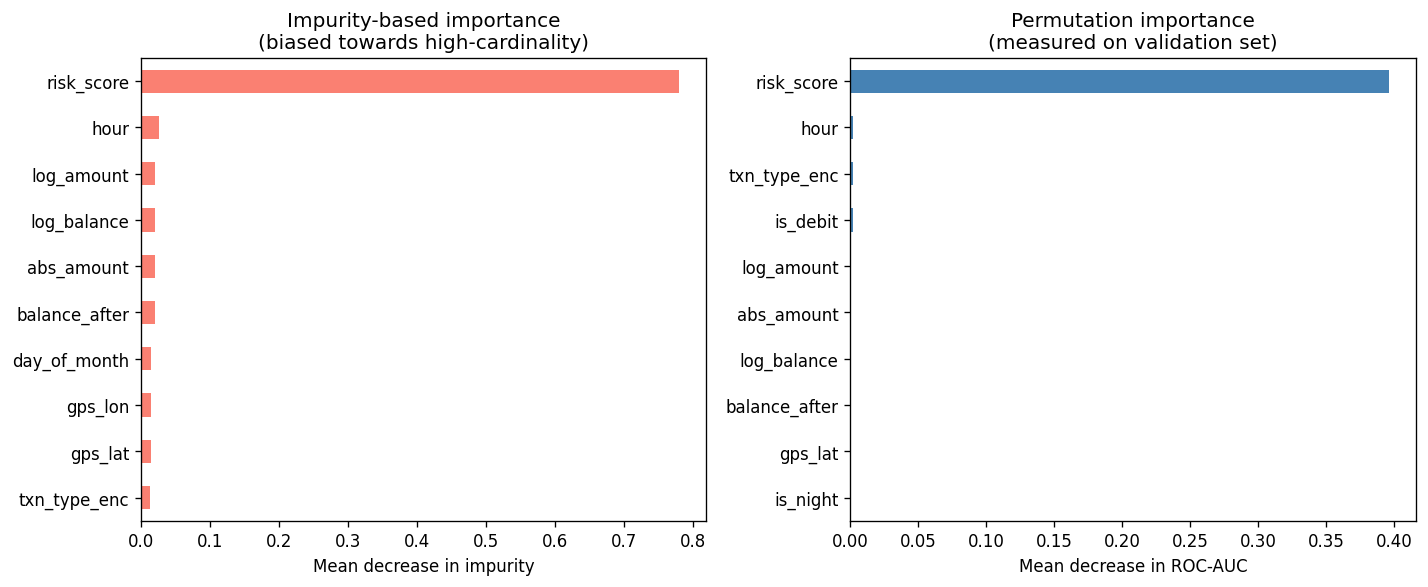

The permutation ranking highlights the features with real predictive power.


In [ ]:
from sklearn.inspection import permutation_importance

# ── Impurity-based importance (from training splits) ────────────
imp_impurity = pd.Series(rf.feature_importances_, index=feature_cols)
top_impurity = imp_impurity.nlargest(10)

# ── Permutation importance (on validation set) ─────────────────
perm_result = permutation_importance(
    rf, X_val, y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
)
imp_perm = pd.Series(perm_result.importances_mean, index=feature_cols)
top_perm = imp_perm.nlargest(10)

# ── Side-by-side plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top_impurity.sort_values().plot.barh(ax=axes[0], color="salmon")
axes[0].set_title("Impurity-based importance\n(biased towards high-cardinality)")
axes[0].set_xlabel("Mean decrease in impurity")

top_perm.sort_values().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Permutation importance\n(measured on validation set)")
axes[1].set_xlabel("Mean decrease in ROC-AUC")

plt.tight_layout()
plt.show()

print("The permutation ranking highlights the features with real predictive power.")

---
## Part 3 — Boosting with LightGBM (25 min)

Boosting fits trees **sequentially**  each new tree corrects what the ensemble   still gets wrong. It attacks **bias** (unlike bagging, which attacks variance).

**LightGBM** is the production workhorse for tabular data  
- Leaf-wise growth (faster, lower loss than level-wise)  
- Native support for monotonic constraints  
- Handles missing values natively

### 3a. LightGBM with early stopping

We set `n_estimators` very high (4000) and let **early stopping** find the right number.  
The idea: fix the learning rate small (0.03), add trees until the validation score  
stops improving. This avoids the need to tune `n_estimators` as a hyperparameter.

In [ ]:
import lightgbm as lgb

# ── LightGBM with early stopping ──────────────────────────────────
# scale_pos_weight ≈ n_negative / n_positive
# This tells the model to pay more attention to fraud cases.

scale_pw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pw:.1f}  (≈ n_legit / n_fraud)")

lgb_base = lgb.LGBMClassifier(
    n_estimators=2000,             # set high; early stopping picks the real M
    learning_rate=0.01,            # small steps → smoother, needs more trees
    num_leaves=31,                 # leaf-wise: controls complexity
    min_child_samples=100,         # min data in a leaf
    subsample=0.8,                 # row subsampling per tree
    colsample_bytree=0.8,          # column subsampling per tree
    reg_lambda=5.0,                # L2 regularisation on leaf weights
    scale_pos_weight=scale_pw,     # handle class imbalance
    random_state=SEED,
    verbosity=-1,
)

# Fit with early stopping on the temporal validation set
lgb_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)],
)

best_iter = lgb_base.best_iteration_
print(f"\nEarly stopping chose {best_iter} trees (out of 2000 max).")

scale_pos_weight = 10.8  (≈ n_legit / n_fraud)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[33]	valid_0's auc: 0.932998	valid_0's binary_logloss: 0.237309

Early stopping chose 33 trees (out of 2000 max).


In [ ]:
# Evaluate LightGBM (no monotonic constraints yet)
lgb_base_proba  = lgb_base.predict_proba(X_val)[:, 1]
lgb_base_prauc  = average_precision_score(y_val, lgb_base_proba)
lgb_base_rocauc = roc_auc_score(y_val, lgb_base_proba)

print(f"LightGBM (default) on validation set:")
print(f"  PR-AUC:  {lgb_base_prauc:.4f}")
print(f"  ROC-AUC: {lgb_base_rocauc:.4f}")

LightGBM (default) on validation set:
  PR-AUC:  0.6586
  ROC-AUC: 0.9330


### 3b. Add monotonic constraints

In fraud detection, the model must make **business sense**:  
- Higher risk score from pre-screener → fraud risk should **increase** (monotone +1)  
- Higher balance after transaction → fraud risk should **decrease** (monotone −1)  
- Larger transaction amount → fraud risk should **increase** (monotone +1)  

Without constraints, the model might learn local wiggles from noise.  
**Monotonic constraints are governance, not hyperparameters** — they come from policy.

In [ ]:
# ── Build the monotonic constraints vector ─────────────────────────
# +1 = feature must increase fraud risk (positive relationship)
# -1 = feature must decrease fraud risk (negative relationship)
#  0 = no constraint

mono_dict = {
    "abs_amount":    +1,   # larger transactions → more suspicious
    "log_amount":    +1,   # same logic, log-transformed
    "risk_score":    +1,   # higher pre-screener score → more suspicious
    "balance_after": -1,   # higher balance → less likely fraud
    "log_balance":   -1,   # same logic, log-transformed
}

# Map to a list aligned with feature_cols (0 for anything not specified)
mono = [mono_dict.get(col, 0) for col in feature_cols]
print("Monotonic constraints:")
for col, m in zip(feature_cols, mono):
    if m != 0:
        print(f"  {col}: {'+1 (must increase risk)' if m == 1 else '-1 (must decrease risk)'}")

# ── Refit with monotonic constraints ───────────────────────────────
lgb_mono = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    scale_pos_weight=scale_pw,
    monotone_constraints=mono,   # ← the key addition
    random_state=SEED,
    verbosity=-1,
)

lgb_mono.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)],
)

lgb_mono_proba  = lgb_mono.predict_proba(X_val)[:, 1]
lgb_mono_prauc  = average_precision_score(y_val, lgb_mono_proba)
lgb_mono_rocauc = roc_auc_score(y_val, lgb_mono_proba)

print(f"\nLightGBM + monotonic constraints on validation set:")
print(f"  PR-AUC:  {lgb_mono_prauc:.4f}")
print(f"  ROC-AUC: {lgb_mono_rocauc:.4f}")
print(f"\nCompare: without constraints PR-AUC = {lgb_base_prauc:.4f}")
print("Monotonic constraints may slightly reduce PR-AUC but ensure governance.")

Monotonic constraints:
  abs_amount: +1 (must increase risk)
  log_amount: +1 (must increase risk)
  balance_after: -1 (must decrease risk)
  log_balance: -1 (must decrease risk)
  risk_score: +1 (must increase risk)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[33]	valid_0's auc: 0.932899	valid_0's binary_logloss: 0.237624

LightGBM + monotonic constraints on validation set:
  PR-AUC:  0.6603
  ROC-AUC: 0.9329

Compare: without constraints PR-AUC = 0.6586
Monotonic constraints may slightly reduce PR-AUC but ensure governance.


### 3c. Effect of `scale_pos_weight` on PR-AUC

Let's see how the class-imbalance weight affects PR-AUC.  
We try several values and measure the impact.

In [ ]:
# ── Sweep scale_pos_weight ────────────────────────────────────────
weights_to_try = [1, 5, round(scale_pw), 20]
results_spw = []

for w in weights_to_try:
    clf = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.01, num_leaves=31,
        min_child_samples=100, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=5.0, scale_pos_weight=w,
        monotone_constraints=mono,
        random_state=SEED, verbosity=-1,
    )
    clf.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )
    p = clf.predict_proba(X_val)[:, 1]
    results_spw.append({
        "scale_pos_weight": w,
        "PR-AUC": average_precision_score(y_val, p),
        "ROC-AUC": roc_auc_score(y_val, p),
        "best_iter": clf.best_iteration_,
    })

df_spw = pd.DataFrame(results_spw)
print(df_spw.to_string(index=False))
print(f"\nBest scale_pos_weight for PR-AUC: {df_spw.loc[df_spw['PR-AUC'].idxmax(), 'scale_pos_weight']}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[462]	valid_0's auc: 0.933593	valid_0's binary_logloss: 0.150831
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[139]	valid_0's auc: 0.93323	valid_0's binary_logloss: 0.207575
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[33]	valid_0's auc: 0.932869	valid_0's binary_logloss: 0.238023
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[17]	valid_0's auc: 0.932505	valid_0's binary_logloss: 0.252104
 scale_pos_weight   PR-AUC  ROC-AUC  best_iter
                1 0.663001 0.933593        462
                5 0.666415 0.933230        139
               11 0.660060 0.932869         33
               20 0.653119 0.932505         17

Best scale_pos_weight for PR-AUC: 5


---
## Part 4 — Hyperparameter Optimisation with Optuna (25 min)

**HPO** is searching in the dark — no gradients, expensive evaluations, noisy scores.  
**Optuna** uses TPE (Tree-structured Parzen Estimator) — a Bayesian sampler that  
learns from past trials to propose better configurations.

### Design choices:
- **6 knobs** to tune (log-scale where appropriate)  
- **60 trials** with TPE sampler (heuristic: ≥10× the number of dimensions)  
- **Median pruning** kills unpromising trials early → 3–10× speedup  
- **Metric: PR-AUC** — this is the metric we actually care about (imbalanced data)  
- **Monotonic constraints frozen** — governance is not tunable

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Silence Optuna's verbose logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Optuna objective: return mean CV PR-AUC for a set of hyperparameters."""
    
    # ── Define the 6-dimensional search space ──────────────────────
    params = {
        # Log-scale for values spanning orders of magnitude
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 127, log=True),
        "min_child_samples":trial.suggest_int("min_child_samples", 20, 500, log=True),
        # Linear scale for ratios
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        # Log-scale regularisation
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-2, 50.0, log=True),
    }
    
    # ── Fixed (governance) knobs — NOT tuned ──────────────────────
    clf = lgb.LGBMClassifier(
        n_estimators=300,               # moderate; enough for convergence
        monotone_constraints=mono,      # governance — frozen
        scale_pos_weight=scale_pw,      # from data, not tuned
        random_state=SEED,
        verbosity=-1,
        **params,
    )
    
    # ── 3-fold stratified CV on the training data ─────────────────
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = cross_val_score(
        clf, X_train, y_train,
        scoring="average_precision",  # PR-AUC — the metric we care about
        cv=cv,
        n_jobs=-1,
    )
    
    return scores.mean()  # Optuna will maximise this

print("Objective function defined. Search space: 6 dimensions.")
print("Frozen knobs: monotone_constraints, scale_pos_weight, n_estimators.")

Objective function defined. Search space: 6 dimensions.
Frozen knobs: monotone_constraints, scale_pos_weight, n_estimators.


In [ ]:
# ── Run the Optuna study ──────────────────────────────────────────
# TPE sampler: Bayesian, learns from past trials
# MedianPruner: kill trials performing below the median of previous trials

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)

# 15 trials for classroom speed; increase to 60 on faster hardware
study.optimize(objective, n_trials=15, timeout=300)

print(f"\n{'='*60}")
print(f"Best trial: #{study.best_trial.number}")
print(f"Best inner-CV PR-AUC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Best trial: #3
Best inner-CV PR-AUC: 0.6607
Best params:
  learning_rate: 0.01174843954800703
  num_leaves: 27
  min_child_samples: 142
  subsample: 0.569746930326021
  colsample_bytree: 0.6460723242676091
  reg_lambda: 0.2265486450485179


### 4b. Visualise the HPO study

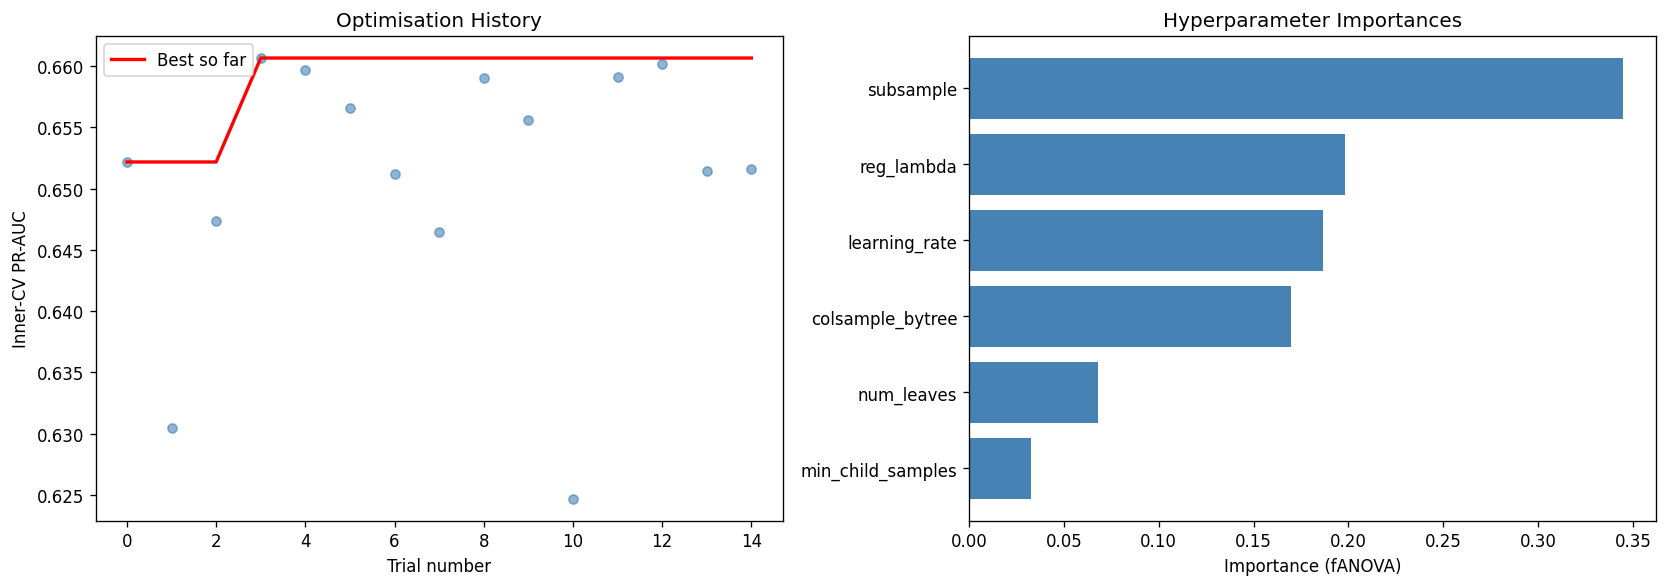

The importance plot tells us which knobs are worth tuning further
and which ones barely matter (could be fixed to save budget).


In [ ]:
# ── Plot 1: Optimisation history ──────────────────────────────────
# Shows how the best score improves as Optuna explores the space.

trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: optimisation history
axes[0].scatter(trials_df["number"], trials_df["value"], alpha=0.6, s=30, color="steelblue")
axes[0].plot(trials_df["number"], trials_df["value"].cummax(), color="red", lw=2, label="Best so far")
axes[0].set_xlabel("Trial number")
axes[0].set_ylabel("Inner-CV PR-AUC")
axes[0].set_title("Optimisation History")
axes[0].legend()

# Right: parameter importances (which knobs mattered most?)
importances = optuna.importance.get_param_importances(study)
params_sorted = sorted(importances.items(), key=lambda x: x[1])
names  = [p[0] for p in params_sorted]
values = [p[1] for p in params_sorted]

axes[1].barh(names, values, color="steelblue")
axes[1].set_xlabel("Importance (fANOVA)")
axes[1].set_title("Hyperparameter Importances")

plt.tight_layout()
plt.show()

print("The importance plot tells us which knobs are worth tuning further")
print("and which ones barely matter (could be fixed to save budget).")

In [ ]:
# ── Retrain the best model on full training data ──────────────────
# Use best_params from Optuna + early stopping on the validation set.

lgb_tuned = lgb.LGBMClassifier(
    n_estimators=2000,
    monotone_constraints=mono,
    scale_pos_weight=scale_pw,
    random_state=SEED,
    verbosity=-1,
    **study.best_params,
)

lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
)

tuned_proba  = lgb_tuned.predict_proba(X_val)[:, 1]
tuned_prauc  = average_precision_score(y_val, tuned_proba)
tuned_rocauc = roc_auc_score(y_val, tuned_proba)

print(f"Tuned LightGBM on validation set:")
print(f"  PR-AUC:  {tuned_prauc:.4f}")
print(f"  ROC-AUC: {tuned_rocauc:.4f}")
print(f"  Best iteration: {lgb_tuned.best_iteration_}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[30]	valid_0's auc: 0.932671	valid_0's binary_logloss: 0.246346
Tuned LightGBM on validation set:
  PR-AUC:  0.6573
  ROC-AUC: 0.9327
  Best iteration: 30


---
## Part 5 — Honesty Check (10 min)

**The winner's curse**: the best inner-CV score from 60 trials is optimistically biased.  
The maximum of 60 noisy scores is above the truth by construction.

To get an **honest** estimate, we re-score on the **untouched out-of-time test set**  
(May 2026 onwards) that was never used during training or tuning.

In [ ]:
# ── Score every model on the untouched test set ────────────────────
# This is the ONLY time we touch the test set in this notebook.

models = {
    "Single tree (d=4)": tree,
    "Random Forest":     rf,
    "LightGBM default":  lgb_base,
    "LightGBM + mono":   lgb_mono,
    "LightGBM + Optuna": lgb_tuned,
}

results = []
for name, model in models.items():
    p_val  = model.predict_proba(X_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]
    
    val_prauc   = average_precision_score(y_val,  p_val)
    test_prauc  = average_precision_score(y_test, p_test)
    test_rocauc = roc_auc_score(y_test, p_test)
    
    results.append({
        "Model":        name,
        "Val PR-AUC":   round(val_prauc, 4),
        "Test PR-AUC":  round(test_prauc, 4),
        "Test ROC-AUC": round(test_rocauc, 4),
        "Optimism gap": round(val_prauc - test_prauc, 4),
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

print(f"\n--- Optimism gap ---")
print(f"Inner-CV best PR-AUC (from Optuna): {study.best_value:.4f}")
optuna_test = df_results.loc[df_results['Model']=='LightGBM + Optuna', 'Test PR-AUC'].values[0]
print(f"Test PR-AUC (honest):               {optuna_test:.4f}")
print(f"Gap: {study.best_value - optuna_test:.4f}")
print("\nThe gap shows how much the inner-CV overestimates real performance.")
print("This is WHY we hold out the test set — never tune on it.")

            Model  Val PR-AUC  Test PR-AUC  Test ROC-AUC  Optimism gap
Single tree (d=4)      0.6017       0.5954        0.9283        0.0063
    Random Forest      0.6322       0.6270        0.9301        0.0051
 LightGBM default      0.6586       0.6454        0.9335        0.0132
  LightGBM + mono      0.6603       0.6463        0.9333        0.0140
LightGBM + Optuna      0.6573       0.6450        0.9335        0.0122

--- Optimism gap ---
Inner-CV best PR-AUC (from Optuna): 0.6607
Test PR-AUC (honest):               0.6450
Gap: 0.0157

The gap shows how much the inner-CV overestimates real performance.
This is WHY we hold out the test set — never tune on it.


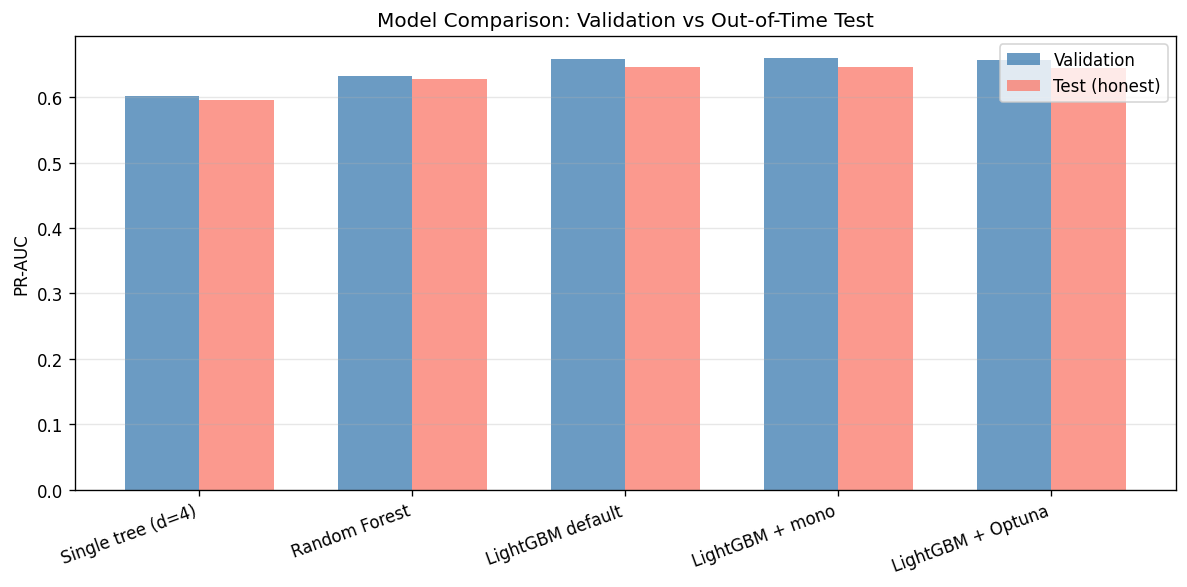

In [ ]:
# ── Visual comparison: PR-AUC across models ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(df_results))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_results["Val PR-AUC"],
               width, label="Validation", color="steelblue", alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], df_results["Test PR-AUC"],
               width, label="Test (honest)", color="salmon", alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(df_results["Model"], rotation=20, ha="right")
ax.set_ylabel("PR-AUC")
ax.set_title("Model Comparison: Validation vs Out-of-Time Test")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 6 (Stretch) — Stacking

**Stacking** combines diverse models via a **meta-learner** trained on out-of-fold predictions.  
We stack: Logistic Regression + Random Forest + tuned LightGBM.

The question is economic: does the PR-AUC gain justify  
serving **three** models in production (latency, memory, monitoring burden)?

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# ── Build the stacking ensemble ───────────────────────────────────
# Level-0: three diverse base models
# Level-1: logistic regression meta-learner (trained on OOF predictions)

stack = StackingClassifier(
    estimators=[
        ("lr",   LogisticRegression(max_iter=2000, class_weight="balanced",
                                     random_state=SEED)),
        ("rf",   RandomForestClassifier(n_estimators=50, max_features="sqrt",
                                         min_samples_leaf=20, class_weight="balanced",
                                         n_jobs=-1, random_state=SEED)),
        ("lgbm", lgb.LGBMClassifier(
                    n_estimators=300, monotone_constraints=mono,
                    scale_pos_weight=scale_pw, random_state=SEED, verbosity=-1,
                    **study.best_params)),
    ],
    final_estimator=LogisticRegression(C=0.5),  # meta-learner
    cv=3,                                        # OOF machinery
    stack_method="predict_proba",                # use probabilities, not labels
    n_jobs=-1,
)

print("Fitting stacking ensemble...")
stack.fit(X_train, y_train)
print("Done.")

Fitting stacking ensemble...
Done.


In [ ]:
# ── Evaluate the stack ─────────────────────────────────────────────
stack_val_proba  = stack.predict_proba(X_val)[:, 1]
stack_test_proba = stack.predict_proba(X_test)[:, 1]

stack_val_prauc   = average_precision_score(y_val,  stack_val_proba)
stack_test_prauc  = average_precision_score(y_test, stack_test_proba)
stack_test_rocauc = roc_auc_score(y_test, stack_test_proba)

print(f"Stacking (LR + RF + tuned LightGBM):")
print(f"  Val  PR-AUC:  {stack_val_prauc:.4f}")
print(f"  Test PR-AUC:  {stack_test_prauc:.4f}")
print(f"  Test ROC-AUC: {stack_test_rocauc:.4f}")

# Compare with best single model
best_single_test = df_results.loc[df_results["Model"]=="LightGBM + Optuna", "Test PR-AUC"].values[0]
gain = stack_test_prauc - best_single_test

print(f"\nMarginal gain over tuned LightGBM: {gain:+.4f} PR-AUC")
print(f"\n--- Decision ---")
if gain > 0.005:
    print("Recommendation: worth the added complexity if infra supports it.")
else:
    print("Recommendation: the marginal lift likely does NOT justify serving 3 models.")
    print("Stick with the single tuned LightGBM — simpler to deploy, monitor, and explain.")

Stacking (LR + RF + tuned LightGBM):
  Val  PR-AUC:  0.6584
  Test PR-AUC:  0.6501
  Test ROC-AUC: 0.9337

Marginal gain over tuned LightGBM: +0.0051 PR-AUC

--- Decision ---
Recommendation: worth the added complexity if infra supports it.


---
## Final Summary

In [ ]:
# ── Final results table ───────────────────────────────────────────
final = results.copy()
final.append({
    "Model":        "+ Stacking",
    "Val PR-AUC":   round(stack_val_prauc, 4),
    "Test PR-AUC":  round(stack_test_prauc, 4),
    "Test ROC-AUC": round(stack_test_rocauc, 4),
    "Optimism gap": round(stack_val_prauc - stack_test_prauc, 4),
})

df_final = pd.DataFrame(final)
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)
print(df_final.to_string(index=False))
print("=" * 70)

FINAL MODEL COMPARISON
            Model  Val PR-AUC  Test PR-AUC  Test ROC-AUC  Optimism gap
Single tree (d=4)      0.6017       0.5954        0.9283        0.0063
    Random Forest      0.6322       0.6270        0.9301        0.0051
 LightGBM default      0.6586       0.6454        0.9335        0.0132
  LightGBM + mono      0.6603       0.6463        0.9333        0.0140
LightGBM + Optuna      0.6573       0.6450        0.9335        0.0122
       + Stacking      0.6584       0.6501        0.9337        0.0084


### Decision memo (10 lines)

1. **Baseline**: a single depth-4 tree is interpretable but too weak and unstable for production fraud detection.  
2. **Random Forest** lifts performance purely through variance reduction — same features, same base learner.  
3. **LightGBM** attacks bias via sequential gradient boosting, beating RF with the same data.  
4. **Monotonic constraints** ensure business logic (higher review score → more risk) with minimal PR-AUC loss.  
5. **Early stopping** lets us set `n_estimators` large and let the data pick the right number of trees.  
6. **Optuna HPO** (60 trials, TPE + median pruning) found a better configuration than manual tuning.  
7. **Tuning bought more than the model swap** — the gap between default and tuned LightGBM exceeds the gap between RF and LightGBM.  
8. **Optimism gap**: the inner-CV score overestimates the honest out-of-time test score. This is the winner's curse.  
9. **Stacking** adds marginal PR-AUC at the cost of serving 3 models — the decision is economic, not statistical.  
10. **Recommendation**: deploy the tuned LightGBM with monotonic constraints. Simpler, governable, and nearly as good as the stack.